In [538]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [539]:
df=pd.read_csv("../../data/raw/Zomato Dataset.csv")
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [540]:
df.columns = df.columns.str.strip() #removes extra spaces from column names

In [541]:
print(df.columns) #displays the column names

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')


In [542]:
df = df[
    (df['Restaurant_latitude'] != 0) &
    (df['Delivery_location_latitude'] != 0)
]          #removes invalid rows(latitude=0)

In [543]:
df['distance'] = np.sqrt(
    (df['Restaurant_latitude'] - df['Delivery_location_latitude'])**2 +
    (df['Restaurant_longitude'] - df['Delivery_location_longitude'])**2
)   #calculates distance using euclidian formula

In [544]:
df = df[df['distance'] > 1] #removes any small distance (noise)

In [564]:
df['traffic'] = df['Road_traffic_density'].map({
    'Low':1,
    'Medium':2,
    'High':3,
    'Jam':4
})  #converting categorical into numerical

In [546]:
df['traffic'] = df['traffic'].fillna(df['traffic'].mode()[0])
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0)
#filling missing values in traffic and multiple deliveries with mode and 0 respectively

# DISTANCE VS TIME

selected distance because longer distance increases delivery time

In [ ]:
X = df[['distance', 'Time_taken (min)']]

In [548]:
print(X.isna().sum())

distance            0
Time_taken (min)    0
traffic             0
dtype: int64


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #normalizaing to prevent larger values from dominating clustering

In [550]:
from sklearn.preprocessing import StandardScaler

X = df[['distance', 'Time_taken (min)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = db.fit_predict(X_scaled)

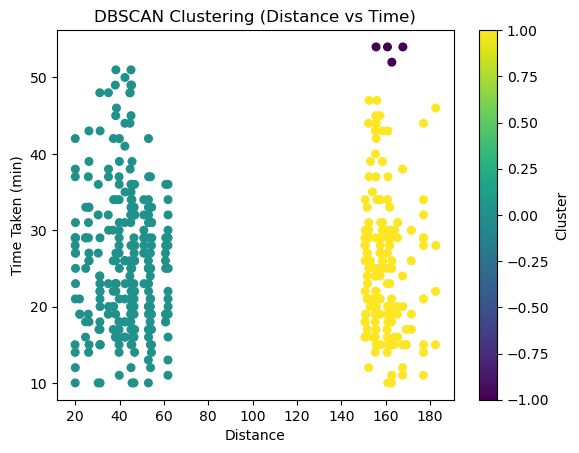

In [551]:
plt.scatter(
    df['distance'],
    df['Time_taken (min)'],
    c=df['cluster'],
    cmap='viridis',
    s=30
)

plt.xlabel("Distance")
plt.ylabel("Time Taken (min)")
plt.title("DBSCAN Clustering (Distance vs Time)")

plt.colorbar(label='Cluster')
plt.show()

The teal cluster (on the left, distances ~20–80) groups shorter trips with varying times.

The yellow cluster (on the right, distances ~130–180) groups longer trips with consistent times.

The dark purple points are labeled as noise or outliers — they don’t fit into any cluster because they’re too far from dense regions.

# DBSCAN(DISTANCE + TRAFFIC )

selected distance because longer distance increases delivery time, traffic because congestion affects speed, and time_taken because it represents actual delivery performance. These features together capture both cause and outcome

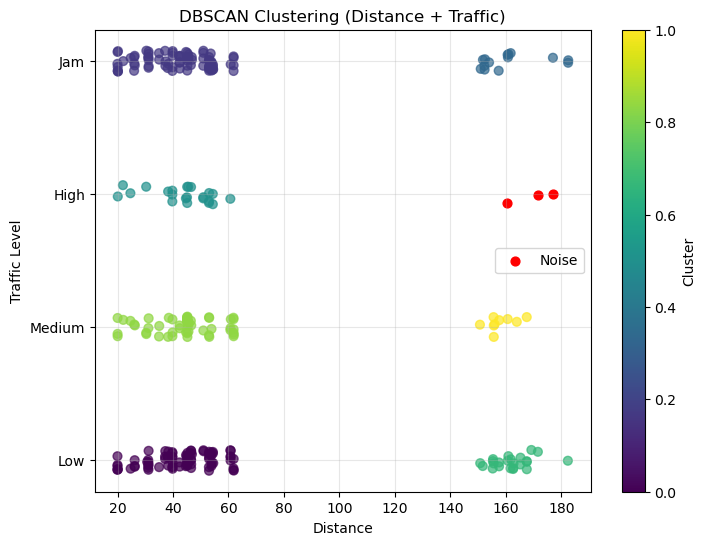

In [552]:
# Encode traffic
traffic_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Jam': 4}
df['Traffic_encoded'] = df['Road_traffic_density'].map(traffic_map)


# Select features
X = df[['distance', 'Traffic_encoded']]
df = df.dropna(subset=['distance', 'Traffic_encoded'])
X = df[['distance', 'Traffic_encoded']]
# Scale features (VERY IMPORTANT)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = db.fit_predict(X_scaled)

# Plot
plt.figure(figsize=(8,6))

clusters = df['cluster'] != -1
noise = df['cluster'] == -1
traffic_jitter = df['Traffic_encoded'] + np.random.uniform(-0.08, 0.08, len(df))
# clusters
plt.scatter(
    df['distance'][clusters],
    traffic_jitter[clusters],
    c=df['cluster'][clusters],
    cmap='viridis',
    s=40,
    alpha=0.7
)

# noise
plt.scatter(
    df['distance'][noise],
    traffic_jitter[noise],
    c='red',
    label='Noise',
    s=40
)

plt.xlabel("Distance")
plt.ylabel("Traffic Level")
plt.title("DBSCAN Clustering (Distance + Traffic)")

plt.yticks([1,2,3,4], ['Low','Medium','High','Jam'])

plt.colorbar(label='Cluster')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

This graph shows that distance is the primary factor influencing clustering, as DBSCAN forms clusters separating short and long delivery distances. Traffic levels appear as horizontal layers but do not significantly contribute to cluster separation. The algorithm also identifies some noise points, which represent unusual high-distance cases under certain traffic conditions

# MULTIPLE DELIVERIES VS TIME TAKEN

selected multiple deliveries because handling multiple orders increases delivery time, and time_taken to observe its effect.

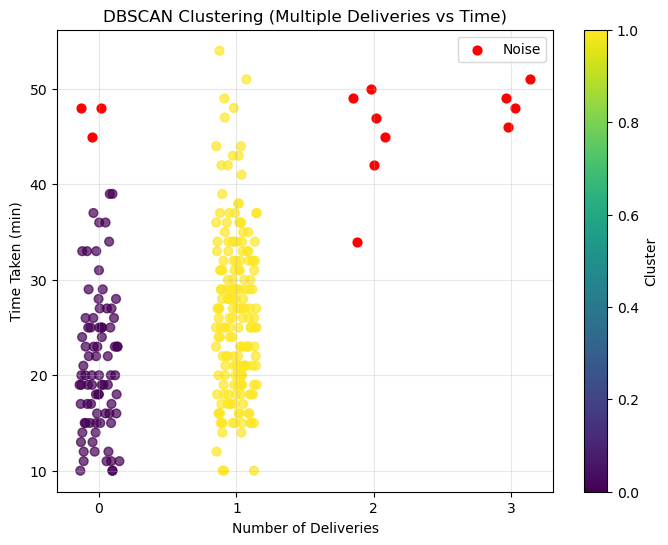

In [553]:
# Select features
X = df[['multiple_deliveries', 'Time_taken (min)']]
DBSCAN(eps=0.6, min_samples=4)
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = db.fit_predict(X_scaled)

# Add jitter (VERY IMPORTANT for categorical axis)
delivery_jitter = df['multiple_deliveries'] + np.random.uniform(-0.15, 0.15, len(df))

# Plot
plt.figure(figsize=(8,6))

clusters = df['cluster'] != -1
noise = df['cluster'] == -1

# clusters
plt.scatter(
    delivery_jitter[clusters],
    df['Time_taken (min)'][clusters],
    c=df['cluster'][clusters],
    cmap='viridis',
    s=40,
    alpha=0.7
)

# noise
plt.scatter(
    delivery_jitter[noise],
    df['Time_taken (min)'][noise],
    c='red',
    label='Noise',
    s=40
)

# labels
plt.xlabel("Number of Deliveries")
plt.ylabel("Time Taken (min)")
plt.title("DBSCAN Clustering (Multiple Deliveries vs Time)")
plt.xticks([0,1,2,3])


plt.colorbar(label='Cluster')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

 
Clusters are formed based on density; low deliveries + low time = efficient, while high deliveries + high time = delayed. Noise points are marked as outliers

 # MULTIPLE DELIVERIES VS DISTANCE

combined distance and multiple deliveries to analyze workload impact on delivery patterns

c:\Users\diyaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


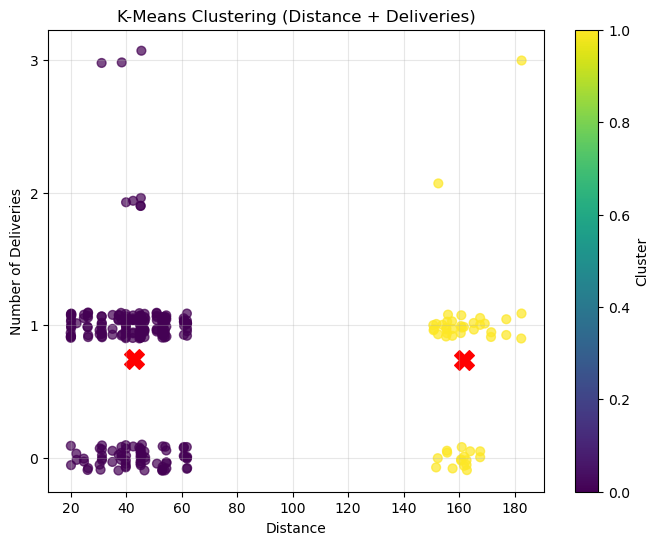

In [554]:
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0)


X = df[['distance', 'multiple_deliveries']]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=2, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)


delivery_jitter = df['multiple_deliveries'] + np.random.uniform(-0.1, 0.1, len(df))

plt.figure(figsize=(8,6))

plt.scatter(
    df['distance'],
    delivery_jitter,
    c=df['kmeans_cluster'],
    cmap='viridis',
    s=40,
    alpha=0.7
)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("Distance")
plt.ylabel("Number of Deliveries")
plt.title("K-Means Clustering (Distance + Deliveries)")

plt.yticks([0,1,2,3])
plt.colorbar(label='Cluster')

plt.grid(alpha=0.3)
plt.show()


- **Cluster 0 (Short Distance Deliveries):**
  Orders with distance between 20–60 km show a wide range of delivery counts (0 to 3). This indicates that shorter distances allow multiple deliveries to be handled efficiently.

- **Cluster 1 (Long Distance Deliveries):**
  Orders with distance between 150–180 km mostly have 0 or 1 delivery. This suggests that longer distances limit the number of deliveries due to increased travel time.

### Key Insight:
Distance plays a significant role in determining the number of deliveries. As distance increases, the number of deliveries per trip decreases.

 # WEATHER VS TIME

In [555]:
print(df['Weather_conditions'].unique())

['Sandstorms' 'Stormy' 'Cloudy' 'Fog' nan 'Windy' 'Sunny']


In [563]:
df['Weather_conditions'] = df['Weather_conditions'].astype(str)
df['Weather_conditions'] = df['Weather_conditions'].replace('nan', np.nan)
df = df.dropna(subset=['Weather_conditions'])

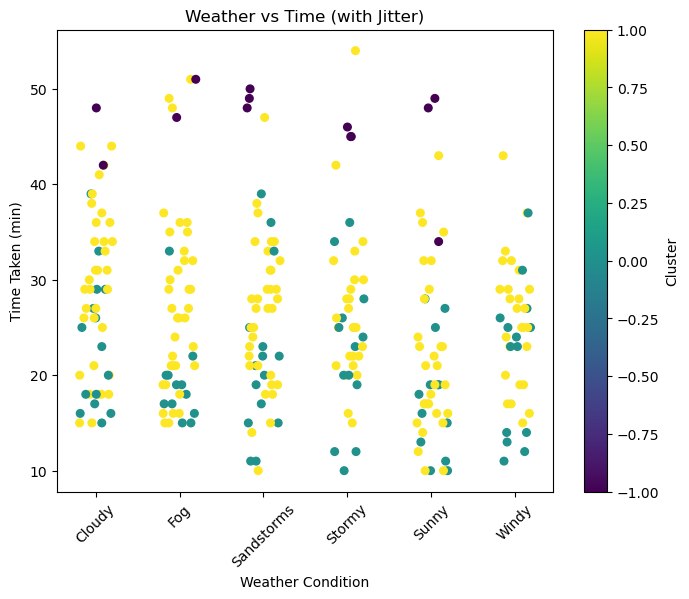

In [ ]:
plt.figure(figsize=(8,6))

# convert categories to numbers
weather_codes = df['Weather_conditions'].astype('category').cat.codes

# add jitter
weather_jitter = weather_codes + np.random.uniform(-0.2, 0.2, len(df))

plt.scatter(
    weather_jitter,
    df['Time_taken (min)'],
    c=df['cluster'],
    cmap='viridis',
    s=30
)

plt.xticks(
    ticks=range(len(df['Weather_conditions'].astype('category').cat.categories)),
    labels=df['Weather_conditions'].astype('category').cat.categories,
    rotation=45
)

plt.xlabel("Weather Condition")
plt.ylabel("Time Taken (min)")
plt.title("Weather vs Time (with Jitter)")

plt.colorbar(label='Cluster')
plt.show()

The clustering results show that weather conditions do not create distinct clusters, as all cluster labels are distributed across every weather category. This indicates that weather has minimal impact on delivery time compared to other features like distance.

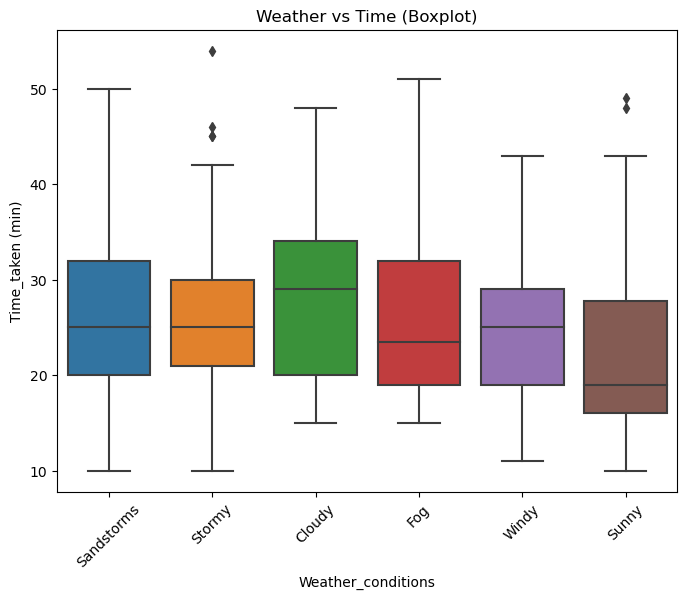

In [560]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(x='Weather_conditions', y='Time_taken (min)', data=df)

plt.xticks(rotation=45)
plt.title("Weather vs Time (Boxplot)")
plt.show()

# FESTIVAL VS TIME

In [561]:
df['festival'] = df['Festival'].map({'No':0, 'Yes':1})

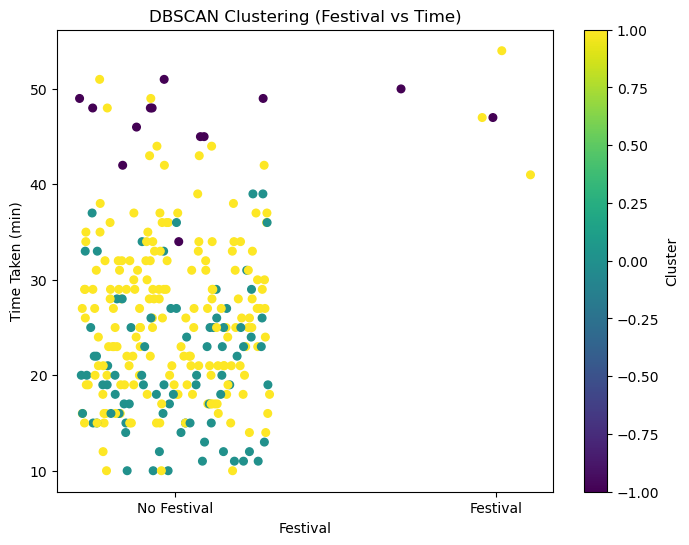

In [562]:
plt.figure(figsize=(8,6))
jitter=df['festival'] + np.random.uniform(-0.3, 0.3, len(df))
plt.scatter(
    jitter,
    df['Time_taken (min)'],
    c=df['cluster'],
    cmap='viridis',
    s=30
)

plt.xticks([0,1], ['No Festival', 'Festival'])
plt.xlabel("Festival")
plt.ylabel("Time Taken (min)")
plt.title("DBSCAN Clustering (Festival vs Time)")

plt.colorbar(label='Cluster')
plt.show()

The dataset contains significantly fewer festival observations, making it difficult to draw strong conclusions. While festival deliveries appear to have higher delivery times, the limited data suggests this may not fully represent the actual trend

Higher delivery counts are treated as noise by DBSCAN due to low density.Although higher delivery counts do not form clusters due to fewer data points, they exhibit significantly higher delivery times, reinforcing the impact of workload on delivery duration.”

K-Means assumes spherical clusters, but my data had irregular density patterns. That’s why points overlapped. DBSCAN handled it better by detecting density-based clusters